# Visual for percolation output

Parsing data from json files, and extracting metrics and configuration

In [115]:
import os
import matplotlib.pyplot as plt
import json

PATH = "/Users/bekor/work/uni_vien/Lab_Stat_Mech/POC/sandbox/notebook"

def read_metrics(file_path):
    with open(file_path, 'r') as file:
        data = json.load(file)
    return data

def extract_metrics(data):
    config = data['config']
    metrics = data['metrics']
    return config, metrics

def calculate_probability_range(config, record_length):
    p0 = config['prob_from']
    p1 = config['prob_to']
    step = config['steps']
    maxv = 65535.0

    x_uint16 = list(range(p0, p1-step, step))
    print(len(x_uint16))
    x_percent = [(v / maxv) * 100 for v in x_uint16]

    return x_percent
    # prob_from = config['prob_from']
    # prob_to = config['prob_to']
    # steps = config['steps']
    # uint16_max = 65535.0
    # print(steps, record_length)
    
    # range_val = prob_to - prob_from
    # to_percent = lambda x: ((prob_from + (x / (steps - 1)) * range_val) / uint16_max) * 100

    # x_percent = [to_percent(i) for i in range(record_length)]
    
    # return x_percent
    

The activation and span plotting functions

In [116]:
def plot_metrics(metrics, config):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    activation = metrics['activation']
    probability = calculate_probability_range(config, len(activation))

    # Plot Probability vs Mean Spanning
    ax1.plot(probability, metrics['spanning'], linestyle='-', color='b')
    ax1.set_title(f'Mean spanning for {config['simulation_number']} on {config['matrix_row']}x{config['matrix_col']} matrix')
    ax1.set_xlabel('Occupation probability %')
    ax1.set_ylabel('Mean Spanning')
    ax1.grid(True)

    # Plot Probability vs Mean Activation
    ax2.plot(probability, metrics['activation'], linestyle='-', color='r')
    ax2.set_title(f'Mean activation for {config['simulation_number']} on {config['matrix_row']}x{config['matrix_col']} matrix')
    ax2.set_xlabel('Occupation probability %')
    ax2.set_ylabel('Mean Activation')
    ax2.grid(True)

    plt.tight_layout()
    plt.savefig('probability_analysis.png')
    
    #     plt.plot(x_range, spanning, color='red')
    # plt.grid(axis='both', color='0.8', linestyle=':')

    print("Plot saved as 'probability_analysis.png'")


In [117]:
# read up all files in the directory and plot the activation metric for each file
all_metrics = list()
def plot_all_activations(directory):
    for filename in os.listdir(directory):
        if filename.startswith("percolation_metrics") and filename.endswith(".json"):
            file_path = os.path.join(directory, filename)
            data = read_metrics(file_path)
            config, metrics = extract_metrics(data)
            all_metrics.append({'config': config, 'metrics': metrics})
            plot_metrics(metrics, config)



200
Plot saved as 'probability_analysis.png'
200
Plot saved as 'probability_analysis.png'


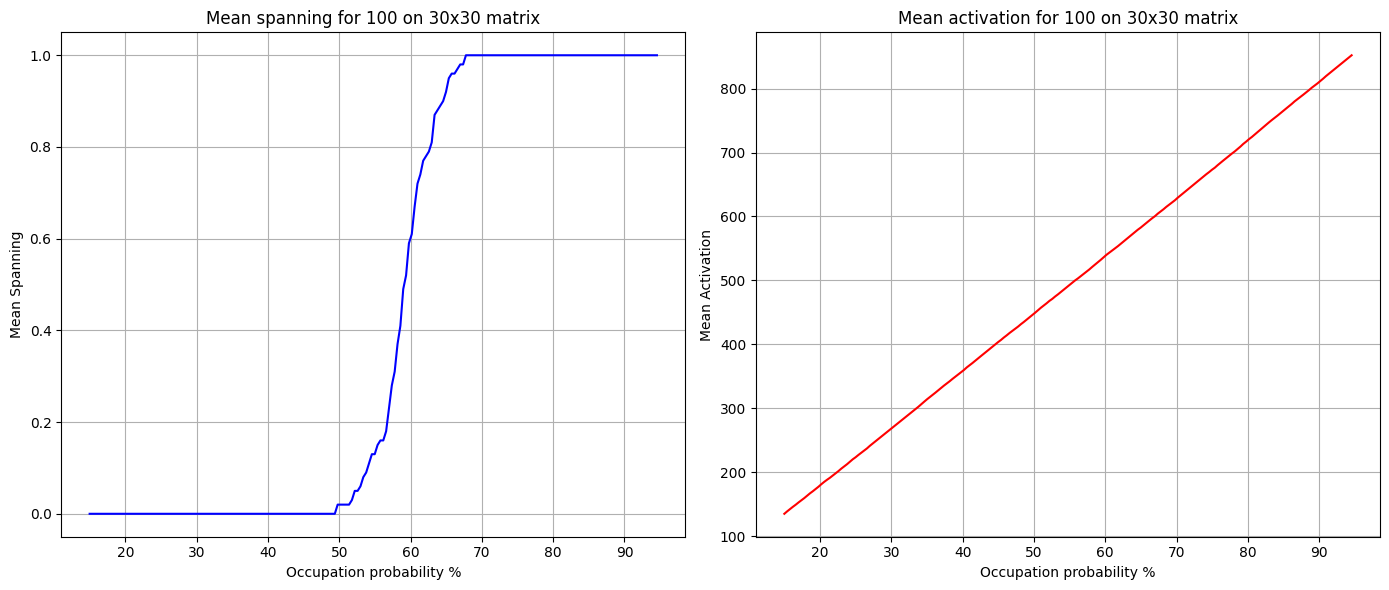

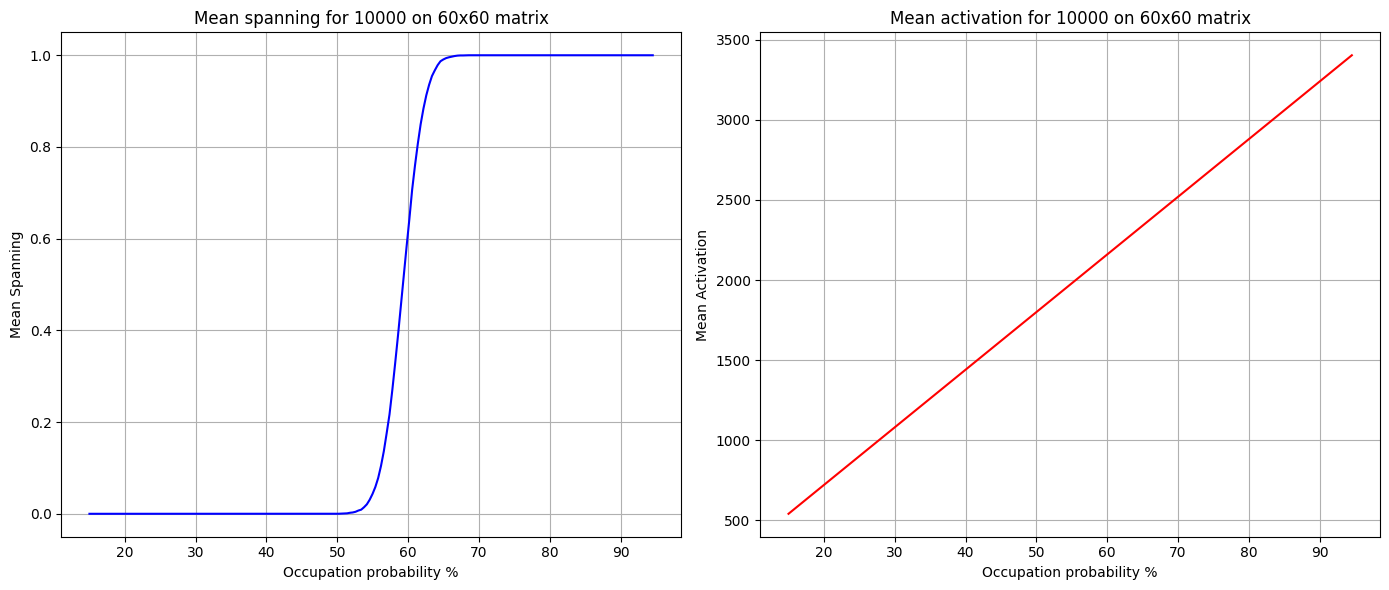

In [118]:
plot_all_activations(PATH)

In [119]:
#find metrics with 60x60 matrix 
metrics_60x60 = [metric for metric in all_metrics if metric['config']['matrix_row'] == 60 and metric['config']['matrix_col'] == 60] 

spanning_60 = metrics_60x60[0]['metrics']['spanning']
print(spanning_60)
# get index of spanning where it is bigger than 0.1 and smaller than 0.9
index_10 = next(i for i, v in enumerate(spanning_60) if v > 0.1)
index_90 = next(i for i, v in enumerate(spanning_60) if v > 0.9)
print(f"Index of spanning > 0.1: {index_10}, Index of spanning > 0.9: {index_90}")

# calculate probability at index 10 and 90
prob_from = metrics_60x60[0]['config']['prob_from']
prob_to = metrics_60x60[0]['config']['prob_to']
steps = metrics_60x60[0]['config']['steps']
uint16_max = 65535.0
range_val = prob_to - prob_from
uint16_value = lambda x: prob_from + (x / (steps - 1)) * range_val
to_percent = lambda x: (uint16_value(x) / uint16_max) * 100
prob_10_not_normalized = uint16_value(index_10)
prob_10 = to_percent(index_10)
prob_90_not_normalized = uint16_value(index_90)
prob_90 = to_percent(index_90)
print(f"Probability at index 10: {prob_10_not_normalized/range_val*uint16_max} {prob_10}%, Probability at index 90: {prob_90_not_normalized/range_val*uint16_max} {prob_90}%")

activation_60 = metrics_60x60[0]['metrics']['activation']
activation_at_10 = activation_60[index_10]
activation_at_90 = activation_60[index_90]
print(f"Activation at index 10: {activation_at_10}, Activation at index 90: {activation_at_90}")


[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0001, 0.0005, 0.0007, 0.001, 0.0022, 0.0029, 0.0044, 0.0071, 0.009, 0.0143, 0.0207, 0.0307, 0.0433, 0.0585, 0.0781, 0.1046, 0.1367, 0.1759, 0.2168, 0.2703, 0.3284, 0.3888, 0.4517, 0.5167, 0.5807, 0.6417, 0.7069, 0.7595, 0.8071, 0.8495, 0.884, 0.9128, 0.9358, 0.9547, 0.9671, 0.9784, 0.9869, 0.9908, 0.9938, 0.9956, 0.997, 0.9983, 0.9992, 0.9996, 0.9996, 0.9999, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 

In [120]:
#find metrics with 60x60 matrix 
metrics_30 = [metric for metric in all_metrics if metric['config']['matrix_row'] == 30 and metric['config']['matrix_col'] == 30] 

spanning_30 = metrics_30[0]['metrics']['spanning']
print(spanning_30)
# get index of spanning where it is bigger than 0.1 and smaller than 0.9
index_10 = next(i for i, v in enumerate(spanning_30) if v > 0.1)
index_90 = next(i for i, v in enumerate(spanning_30) if v > 0.9)
index_50 = next(i for i, v in enumerate(spanning_30) if v > 0.5)
index_60 = next(i for i, v in enumerate(spanning_30) if v > 0.65)
prob_range = calculate_probability_range(metrics_30[0]["config"], len(metrics_30[0]["metrics"]['spanning']))
print(f"Index of spanning > 0.1: {index_10}, Index of spanning > 0.9: {index_90}")
print(f"Index of spanning > 0.5: {index_50}, Index of spanning > 0.6: {index_60}")



idx_10_at60_of_30 = spanning_30[index_10]
idx_90_at60_of_30 = spanning_30[index_90]
print(f"Probability of spanning for 10% of 60x60 matrix: {spanning_60[index_10]}, same index for 30x30 {idx_10_at60_of_30},")
print(f"Probability of spanning for 90% of 60x60 matrix: {spanning_60[index_90]}, same index for 30x30 {idx_90_at60_of_30}")

# calculate probability at index 10 and 90
prob_10_not_normalized = uint16_value(index_10)
prob_10 = to_percent(index_10)
prob_90_not_normalized = uint16_value(index_90)
prob_90 = to_percent(index_90)
print(f"Probability at index 10: {prob_10_not_normalized/range_val*uint16_max} {prob_10}%, Probability at index 90: {prob_90_not_normalized/range_val*uint16_max} {prob_90}%")

activation_30 = metrics_30[0]['metrics']['activation']
activation_at_10 = activation_30[index_10]
activation_at_90 = activation_30[index_90]
print(f"Activation at index 10: {activation_at_10}, Activation at index 90: {activation_at_90}")


[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.02, 0.02, 0.02, 0.02, 0.02, 0.03, 0.05, 0.05, 0.06, 0.08, 0.09, 0.11, 0.13, 0.13, 0.15, 0.16, 0.16, 0.18, 0.23, 0.28, 0.31, 0.37, 0.41, 0.49, 0.52, 0.59, 0.61, 0.67, 0.72, 0.74, 0.77, 0.78, 0.79, 0.81, 0.87, 0.88, 0.89, 0.9, 0.92, 0.95, 0.96, 0.96, 0.97, 0.98, 0.98, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 

In [121]:
import numpy as np
from scipy.interpolate import interp1d

# make sure arrays
x = np.array(prob_range)
y = np.array(spanning_60)

# sort (important if not already sorted)
idx = np.argsort(x)
x, y = x[idx], y[idx]

# interpolate inverse: y -> x
f_inv = interp1d(y, x)

x_at_05 = f_inv(0.5)
print(x_at_05)

59.27319165918388


# Read up metrics from uncorrelated h5

In [122]:
import h5py

metrics = dict()

with h5py.File("metrics_30x30_1000.h5", "r") as f:
    prob       = f["probability"][:]   # (n_metrics,)
    activation = f["activation"][:]    # (n_metrics,)
    spanning   = f["spanning"][:]      # (n_metrics, n_steps)
    evolution  = f["evolution"][:]     # (n_metrics, n_steps, rows*cols)
    metrics = {
        'probability': prob,
        'activation': activation,
        'spanning': spanning,
        'evolution': evolution
    }

In [123]:
print(metrics['probability'].shape)
print(metrics['activation'].shape)
print(metrics['spanning'].shape)
print(metrics['evolution'].shape)


(1700,)
(1700,)
(1700, 1000)
(1700, 1000, 900)


In [124]:
import cv2
import numpy as np

def generate_video_from_flat_vectors(data_sequence, output_filename='output.mp4', fps=10, scale_factor=20):
    print(data_sequence.shape)
    height, width = 30, 30
    scaled_dims = (width * scale_factor, height * scale_factor)
    
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_filename, fourcc, fps, scaled_dims, isColor=False)
    
    for flat_frame in data_sequence:
        arr = np.array(flat_frame, dtype=np.uint8)
        arr = np.array(flat_frame, dtype=np.uint8)
        matrix = arr.reshape(30, 30)
        frame = matrix * 255
        scaled_frame = cv2.resize(frame, scaled_dims, interpolation=cv2.INTER_NEAREST)
        
        out.write(scaled_frame)
        
    out.release()
    print(f"Video saved as {output_filename}")

# generate_video_from_flat_vectors(metrics['evolution'][0], "uncorr_1000_30x30.mp4", 30)

In [125]:
def plot_uncorr_data(mean_data):
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    # Plot Probability vs Mean Spanning
    ax1.plot(mean_data['probability'], mean_data['spanning'], marker='o', linestyle='-', color='b')
    ax1.set_title('Probability vs Mean Spanning')
    ax1.set_xlabel('Probability')
    ax1.set_ylabel('Mean Spanning')
    ax1.grid(True)

    # Plot Probability vs Mean Activation
    # ax2.plot(mean_data['probability'], mean_data['activation'], marker='o', linestyle='-', color='r')
    # ax2.set_title('Probability vs Mean Activation')
    # ax2.set_xlabel('Probability')
    # ax2.set_ylabel('Mean Activation')
    # ax2.grid(True)

    plt.tight_layout()
    plt.savefig('probability_analysis.png')
    print("Plot saved as 'probability_analysis.png'")

In [126]:
import pandas as pd

probability = np.array(metrics['probability']).flatten()
activation = np.array(metrics['activation']).flatten()
spanning_array = np.array(metrics['spanning'])
spanning_summed = spanning_array.sum(axis=1) / spanning_array.shape[1]
print(spanning_array.shape[1])
print(probability.shape)
print(activation.shape)
print(spanning_summed.shape)


data = pd.DataFrame({
    'probability': probability,
    'activation': activation,
    'spanning': spanning_summed
})

1000
(1700,)
(1700,)
(1700,)


Plot saved as 'probability_analysis.png'


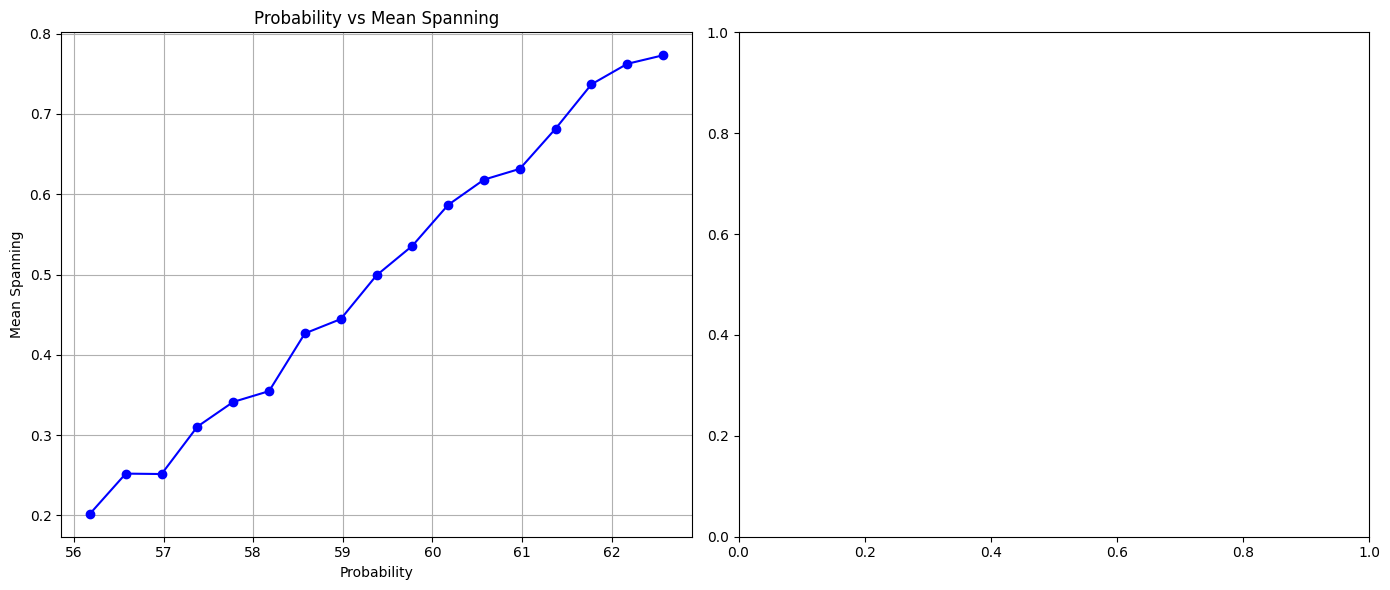

In [127]:
mean_data = data.groupby('probability').mean().reset_index()
plot_uncorr_data(mean_data)

# Spanning fluctuation for every probability

In [128]:
def plot_spanning_with_fluctuation(stats):
    plt.figure(figsize=(10, 6))

    # Line for mean
    plt.plot(stats['probability'], stats['mean'], color='red', label='Mean')

    # Shadow for fluctuation
    plt.fill_between(stats['probability'], 
                    stats['mean'] - stats['std'], 
                    stats['mean'] + stats['std'], 
                    color='red', alpha=0.2, label='Fluctuation (Std)')

    plt.xlabel('Probability')
    plt.ylabel('Spanning')
    plt.title('Spanning with Fluctuation')
    plt.legend()
    plt.grid(True, linestyle=':')
    plt.show()

In [129]:
# Group data by probability and aggregate mean and standard deviation
stats = data.groupby('probability')['spanning'].agg(['mean', 'std']).reset_index()

print(stats.to_string())


    probability     mean       std
0     56.177616  0.20207  0.161560
1     56.577404  0.25210  0.159298
2     56.977188  0.25158  0.168493
3     57.376976  0.31064  0.184154
4     57.776760  0.34136  0.199013
5     58.176548  0.35479  0.214267
6     58.576332  0.42668  0.191082
7     58.976120  0.44448  0.204534
8     59.375908  0.49899  0.202749
9     59.775692  0.53576  0.203827
10    60.175480  0.58671  0.186877
11    60.575264  0.61814  0.185103
12    60.975052  0.63155  0.212908
13    61.374836  0.68167  0.187487
14    61.774624  0.73684  0.171772
15    62.174408  0.76234  0.174229
16    62.574196  0.77299  0.158606


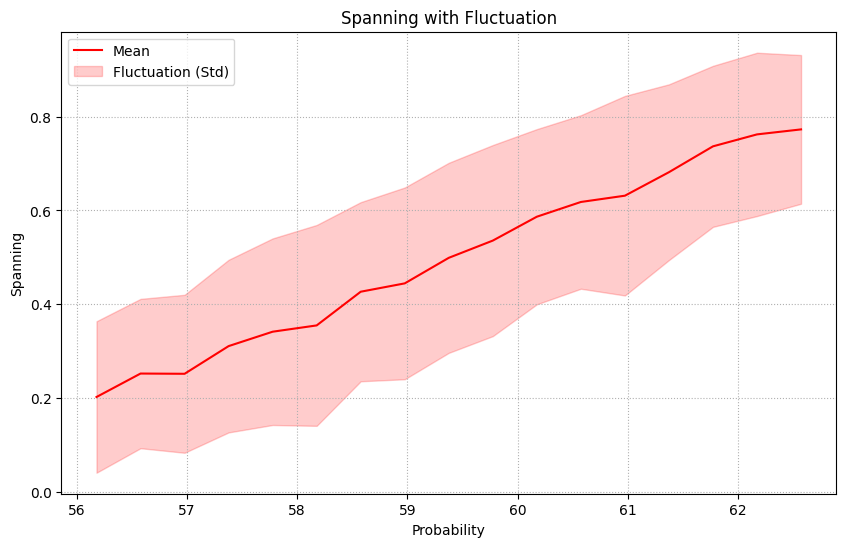

In [ ]:
# plot_spanning_with_fluctuation(stats)

# Handling ising model

In [131]:
ising_metrics = dict()

with h5py.File("ising_metrics_30x30_1000.h5", "r") as f:
    prob       = f["probability"][:]   # (n_metrics,)
    initial_activation = f["initial_activation"][:]    # (n_metrics,)
    initial_energy = f["initial_energy"][:] # (n_metrics,)
    spanning   = f["spanning"][:]      # (n_metrics, n_steps)
    evolution  = f["evolution"][:]     # (n_metrics, n_steps, rows*cols)
    acceptance = f["acceptance"][:] # (n_metrics, n_steps)
    net_energy = f["net_energy"][:] # (n_metrics, n_steps)
    activation = f["activation"][:] # (n_metrics, n_steps)
    ising_metrics = {
        'probability': prob,
        'initial_activation': initial_activation,
        'initial_energy': initial_energy,
        'spanning': spanning,
        'evolution': evolution,
        'acceptance': acceptance,
        'net_energy': net_energy,
        'activation': activation
    }

In [132]:
print(ising_metrics["probability"])
print(ising_metrics["evolution"].shape)
print(ising_metrics["evolution"].dtype)
# portion = ising_metrics['evolution'][0][0]
# portion = portion.reshape(30,30)
# print(portion)
generate_video_from_flat_vectors(ising_metrics['evolution'][0], "ising_out.mp4", 30)

[56.177616 56.577404 56.97719  ... 61.774624 62.174408 62.574196]
(1700, 1000, 900)
uint8
(1000, 900)
Video saved as ising_out.mp4


In [133]:

ising_probability = np.array(ising_metrics['probability']).flatten()
ising_activation = np.array(ising_metrics['activation'])
ising_activation_summed = ising_activation.sum(axis=1) / ising_activation.shape[1]
ising_spanning_array = np.array(ising_metrics['spanning'])
ising_spanning_summed = spanning_array.sum(axis=1)
ising_spanning = ising_spanning_array.sum(axis=1) / ising_spanning_array.shape[1]
ising_energy_array = np.array(ising_metrics['net_energy'])
ising_acc_array = np.array(ising_metrics['acceptance'])
ising_energy_summed = ising_energy_array.sum(axis=1) / ising_energy_array.shape[1]

print(ising_probability.shape)
print(ising_activation.shape)
print(ising_spanning_summed.shape)
# print(ising_energy_array.shape)
# en_144 = [x for x in ising_energy_array if ising_energy_array[0] == 144]
# print(en_144)
ising_data = pd.DataFrame({
    'probability': ising_probability,
    'activation': ising_activation_summed,
    'spanning': ising_spanning,
})

(1700,)
(1700, 1000)
(1700,)


Plot saved as 'probability_analysis.png'


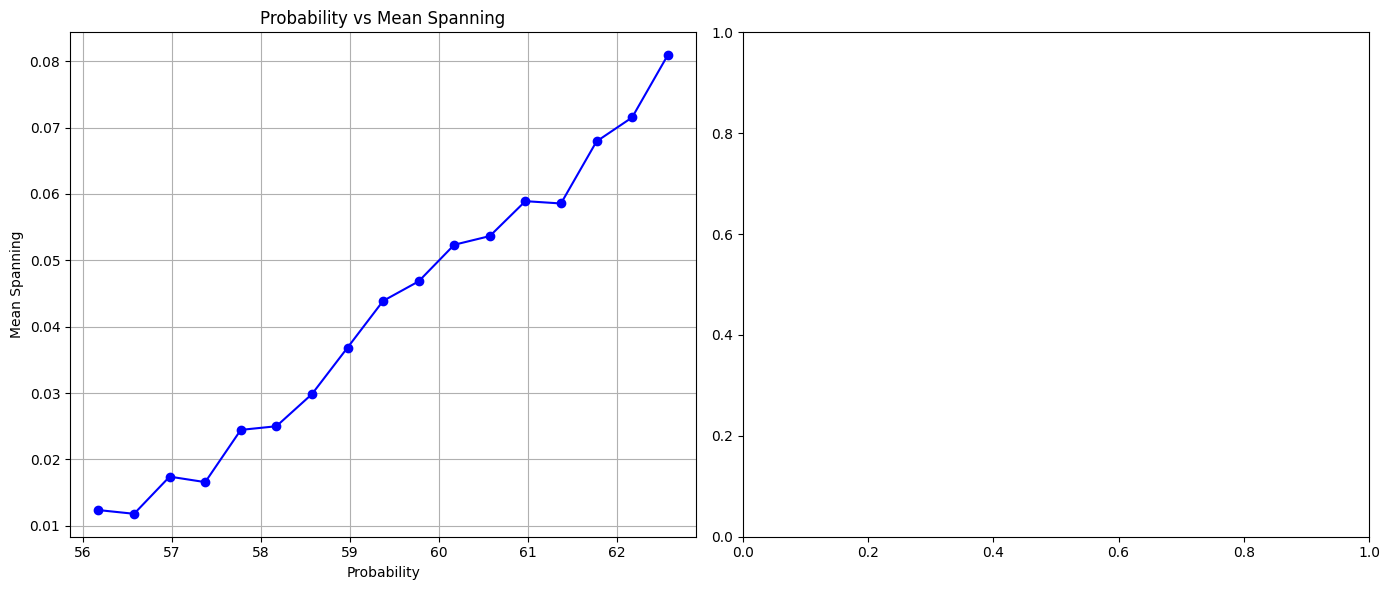

In [134]:
ising_mean_data = ising_data.groupby('probability').mean().reset_index()
plot_uncorr_data(ising_mean_data)

    probability     mean       std
0     56.177616  0.01238  0.035999
1     56.577404  0.01182  0.028870
2     56.977188  0.01742  0.034419
3     57.376976  0.01659  0.032736
4     57.776760  0.02446  0.041818
5     58.176548  0.02501  0.041758
6     58.576332  0.02985  0.043641
7     58.976120  0.03685  0.051493
8     59.375908  0.04389  0.050531
9     59.775692  0.04684  0.056686
10    60.175480  0.05235  0.058455
11    60.575264  0.05366  0.053541
12    60.975052  0.05892  0.057781
13    61.374836  0.05857  0.056147
14    61.774624  0.06792  0.066521
15    62.174408  0.07153  0.059425
16    62.574196  0.08090  0.062259


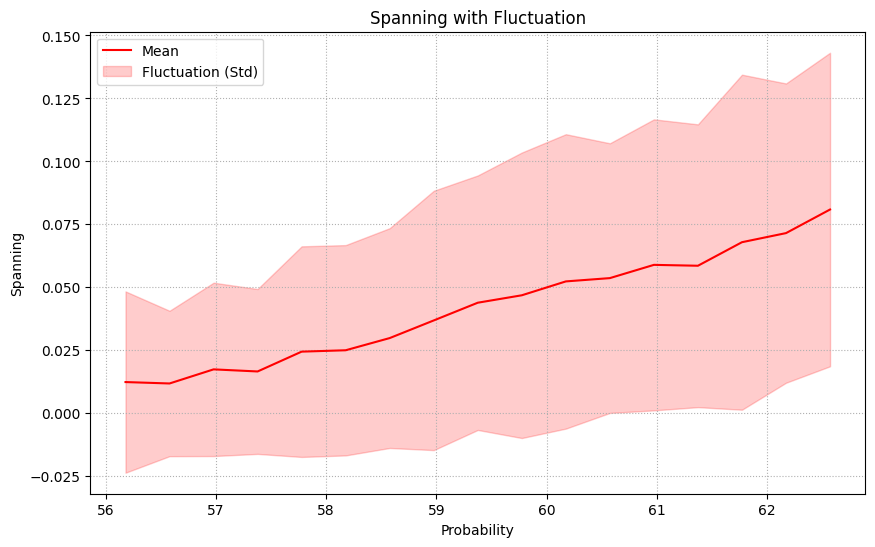

In [ ]:

ising_stats = ising_data.groupby('probability')['spanning'].agg(['mean', 'std']).reset_index()

print(ising_stats.to_string())
# plot_spanning_with_fluctuation(ising_stats)

Plot saved as 'probability_analysis_uncorr_ising.png'


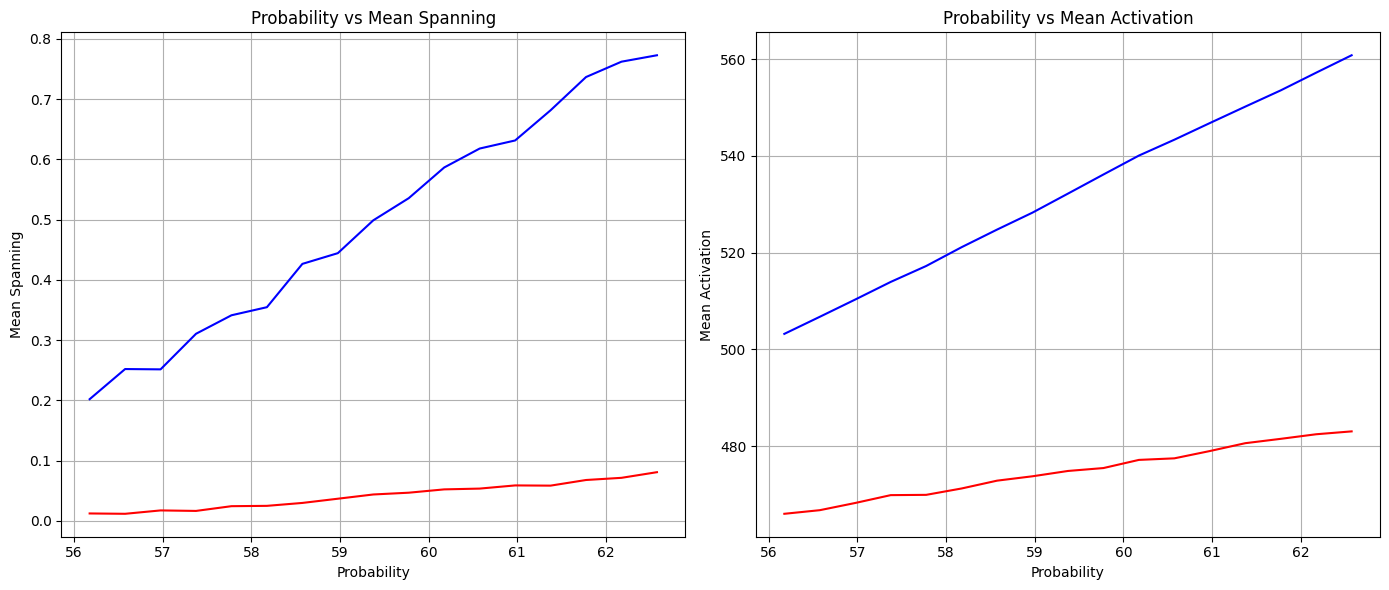

In [136]:
def plot_spanning_data(data1, data2):
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    # Plot Probability vs Mean Spanning
    ax1.plot(data1['probability'], data1['spanning'], label='uncor', linestyle='-', color='b')
    ax1.plot(data2['probability'], data2['spanning'], label='ising', linestyle='-', color='r')
    ax1.set_title('Probability vs Mean Spanning')
    ax1.set_xlabel('Probability')
    ax1.set_ylabel('Mean Spanning')
    ax1.grid(True)

    # Plot Probability vs Mean Activation
    ax2.plot(data1['probability'], data1['activation'], label='uncor', linestyle='-', color='b')
    ax2.plot(data2['probability'], data2['activation'], label='ising', linestyle='-', color='r')
    ax2.set_title('Probability vs Mean Activation')
    ax2.set_xlabel('Probability')
    ax2.set_ylabel('Mean Activation')
    ax2.grid(True)

    plt.tight_layout()
    plt.savefig('probability_analysis_uncorr_ising.png')
    print("Plot saved as 'probability_analysis_uncorr_ising.png'")


plot_spanning_data(mean_data, ising_mean_data)



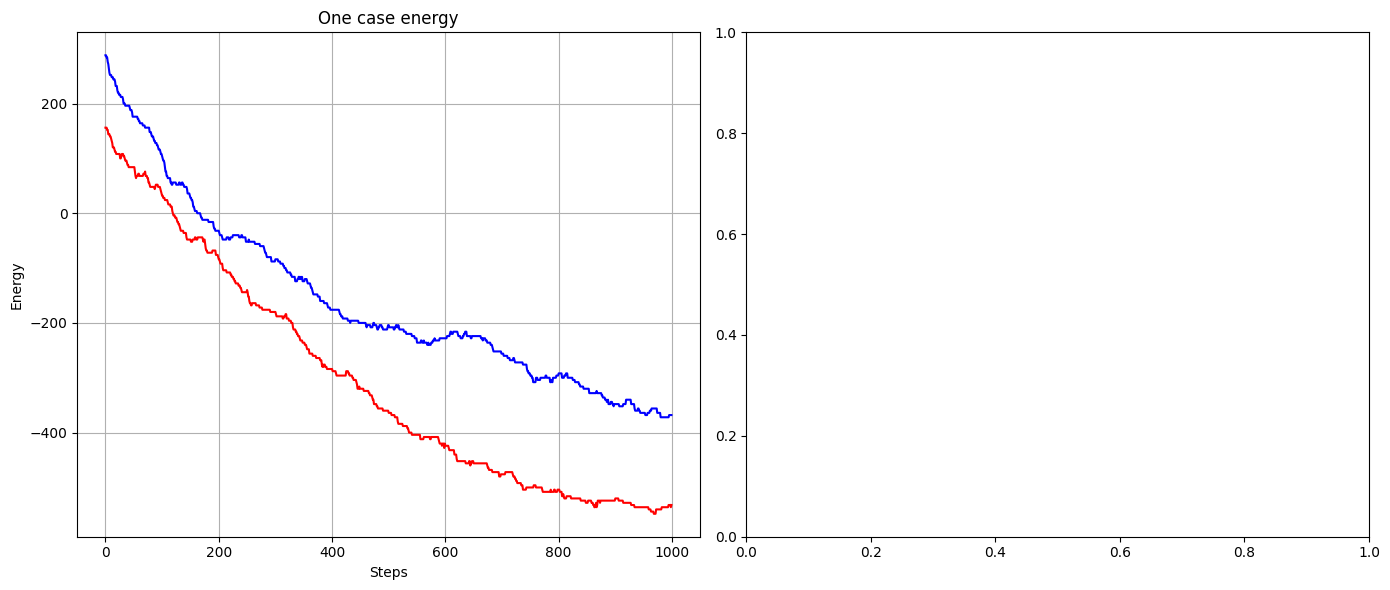

In [137]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.plot(ising_energy_array[0], label='en', linestyle='-', color='r')
ax1.set_title('One case energy')
ax1.set_xlabel('Steps')
ax1.set_ylabel('Energy')
ax1.grid(True)

ax1.plot(ising_energy_array[99], label='en', linestyle='-', color='b')
ax1.set_title('One case energy')
ax1.set_xlabel('Steps')
ax1.set_ylabel('Energy')
ax1.grid(True)

plt.tight_layout()

In [138]:
ising_metrics_sub = dict()

with h5py.File("ising_metrics_30x30_100000_08.h5", "r") as f:
    prob       = f["probability"][:]   # (n_metrics,)
    initial_activation = f["initial_activation"][:]    # (n_metrics,)
    initial_energy = f["initial_energy"][:] # (n_metrics,)
    spanning   = f["spanning"][:]      # (n_metrics, n_steps)
    evolution  = f["evolution"][:]     # (n_metrics, n_steps, rows*cols)
    net_energy = f["net_energy"][:] # (n_metrics, n_steps)
    acceptance = f["acceptance"][:]
    ising_metrics_sub = {
        'probability': prob,
        'initial_activation': initial_activation,
        'initial_energy': initial_energy,
        'spanning': spanning,
        'evolution': evolution,
        'net_energy': net_energy,
        'acceptance': acceptance
    }

In [139]:
print(ising_metrics_sub["probability"])
print(ising_metrics_sub["evolution"].shape)
print(ising_metrics_sub["evolution"].dtype)
# portion = ising_metrics['evolution'][0][0]
# portion = portion.reshape(30,30)
# print(portion)
generate_video_from_flat_vectors(ising_metrics_sub['evolution'][0], "ising_out_sub.mp4", 30)

[59.375908 59.775692 60.17548 ]
(3, 100000, 900)
uint8
(100000, 900)
Video saved as ising_out_sub.mp4


In [140]:
ising_probability = np.array(ising_metrics_sub['probability']).flatten()
ising_spanning_array = np.array(ising_metrics_sub['spanning'])
ising_spanning = ising_spanning_array.sum(axis=1) / ising_spanning_array.shape[1]
ising_energy_array = np.array(ising_metrics_sub['net_energy'])
ising_acc_array = np.array(ising_metrics_sub['acceptance'])
ising_energy_summed = ising_energy_array.sum(axis=1) / ising_energy_array.shape[1]

print(ising_probability.shape)
# print(ising_energy_array.shape)
# en_144 = [x for x in ising_energy_array if ising_energy_array[0] == 144]
# print(en_144)
ising_data = pd.DataFrame({
    'probability': ising_probability,
    'spanning': ising_spanning,
})

(3,)


Plot saved as 'probability_analysis.png'


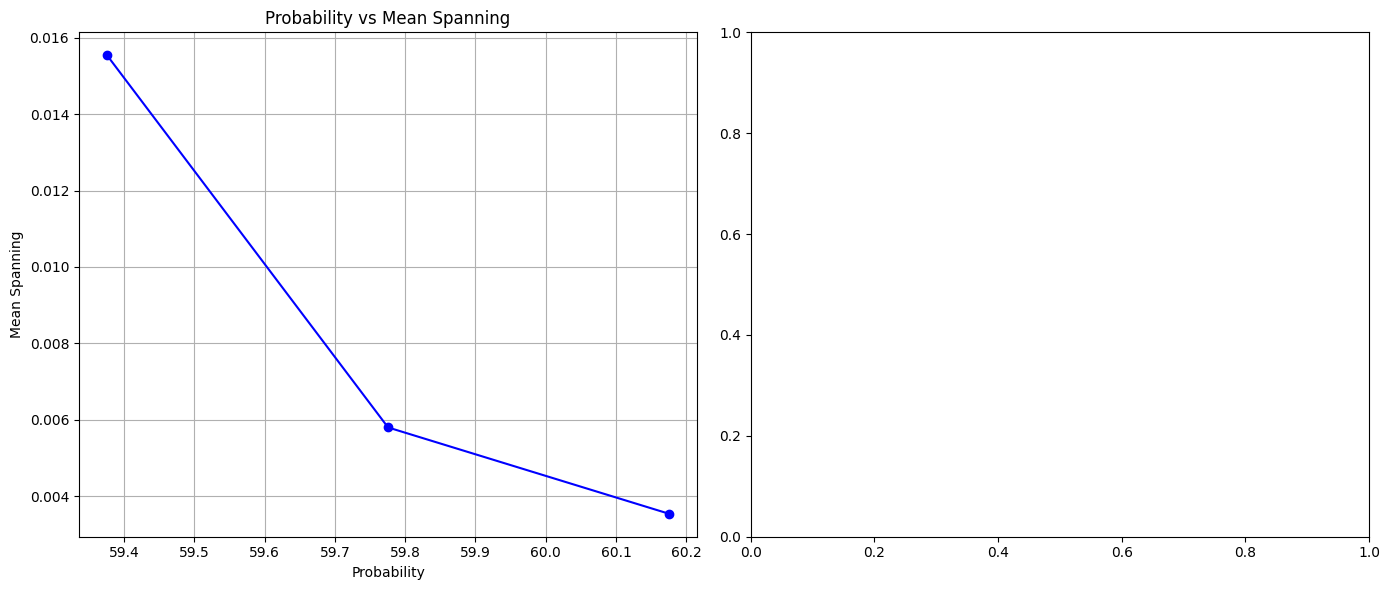

In [141]:
ising_mean_data = ising_data.groupby('probability').mean().reset_index()
plot_uncorr_data(ising_mean_data)

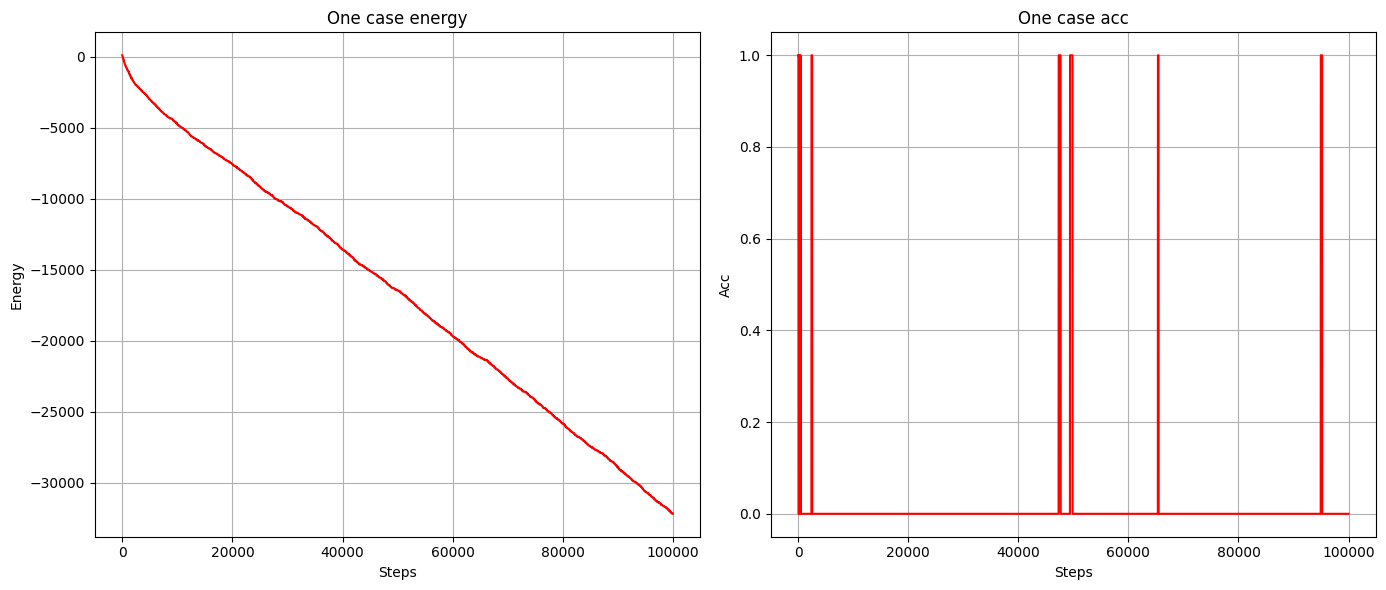

In [142]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.plot(ising_energy_array[0], label='en', linestyle='-', color='r')
ax1.set_title('One case energy')
ax1.set_xlabel('Steps')
ax1.set_ylabel('Energy')
ax1.grid(True)
ax2.plot(ising_spanning_array[0], label='en', linestyle='-', color='r')
ax2.set_title('One case acc')
ax2.set_xlabel('Steps')
ax2.set_ylabel('Acc')
ax2.grid(True)

plt.tight_layout()

In [ ]:
def draw_indicator(frame, condition, center=(15, 15), radius=10):
    if condition:
        cv2.circle(
            frame,
            center=center,
            radius=radius,
            color=(0, 0, 255),  # red (BGR)
            thickness=-1
        )
    return frame

def generate_video_from_flat_vectors_span(data_sequence, spanning, output_filename='output.mp4', fps=10, scale_factor=20):
    print(data_sequence.shape)

    height, width = 30, 30
    scaled_dims = (width * scale_factor, height * scale_factor)
    
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_filename, fourcc, fps, scaled_dims, isColor=True)
    # out = cv2.VideoWriter(output_filename, fourcc, fps, scaled_dims, isColor=False)
    for i, flat_frame in enumerate(data_sequence):
        matrix = np.array(flat_frame, dtype=np.uint8).reshape(30, 30)
        # frame = np.array(flat_frame, dtype=np.uint8).reshape(30, 30) * 255
        color_frame = np.zeros((30, 30, 3), dtype=np.uint8)
        color_frame = np.zeros((30, 30, 3), dtype=np.uint8)
        scaled_frame = cv2.resize(color_frame, scaled_dims, interpolation=cv2.INTER_NEAREST)
        
        # convert grayscale → BGR
        # scaled_frame = cv2.cvtColor(scaled_frame, cv2.COLOR_GRAY2BGR)
        # condition
        scaled_frame = draw_indicator(scaled_frame, spanning[i])
        out.write(scaled_frame)
        
    out.release()
    print(f"Video saved as {output_filename}")

In [162]:
spanning_idxs = [idx for idx, e in enumerate(ising_metrics_sub['spanning'][0]) if e == 1 ]
print(len(spanning_idxs))
print(spanning_idxs[1400:])


1554
[95038, 95039, 95040, 95041, 95042, 95043, 95044, 95045, 95046, 95047, 95048, 95049, 95050, 95051, 95052, 95053, 95054, 95055, 95056, 95057, 95058, 95059, 95060, 95061, 95062, 95063, 95064, 95065, 95066, 95067, 95068, 95069, 95070, 95071, 95072, 95073, 95074, 95075, 95076, 95077, 95078, 95079, 95080, 95081, 95082, 95083, 95084, 95085, 95086, 95087, 95088, 95089, 95090, 95091, 95092, 95093, 95094, 95095, 95096, 95097, 95098, 95099, 95100, 95101, 95102, 95103, 95104, 95105, 95106, 95107, 95108, 95109, 95110, 95111, 95112, 95113, 95114, 95115, 95116, 95117, 95118, 95119, 95120, 95121, 95122, 95123, 95124, 95125, 95126, 95127, 95128, 95129, 95130, 95131, 95132, 95133, 95134, 95135, 95136, 95137, 95138, 95139, 95140, 95141, 95142, 95143, 95144, 95145, 95146, 95147, 95148, 95149, 95150, 95151, 95152, 95153, 95154, 95155, 95156, 95157, 95158, 95159, 95160, 95161, 95162, 95163, 95164, 95165, 95166, 95167, 95168, 95169, 95170, 95171, 95172, 95173, 95174, 95175, 95176, 95177, 95178, 95179, 

In [165]:
generate_video_from_flat_vectors_span(ising_metrics_sub['evolution'][0], ising_metrics_sub['spanning'][0], "ising_out_sub_col.mp4", 60)

(100000, 900)


error: OpenCV(4.13.0) /Users/xperience/GHA-OpenCV-Python/_work/opencv-python/opencv-python/opencv/modules/imgproc/src/color.simd_helpers.hpp:92: error: (-15:Bad number of channels) in function 'cv::impl::(anonymous namespace)::CvtHelper<cv::impl::(anonymous namespace)::Set<1>, cv::impl::(anonymous namespace)::Set<3, 4>, cv::impl::(anonymous namespace)::Set<0, 2, 5>>::CvtHelper(InputArray, OutputArray, int) [VScn = cv::impl::(anonymous namespace)::Set<1>, VDcn = cv::impl::(anonymous namespace)::Set<3, 4>, VDepth = cv::impl::(anonymous namespace)::Set<0, 2, 5>, sizePolicy = cv::impl::(anonymous namespace)::NONE]'
> Invalid number of channels in input image:
>     'VScn::contains(scn)'
> where
>     'scn' is 3
